<a href="https://colab.research.google.com/github/ryrynbob/ust-deep-learning-2026/blob/main/Refinement_Part_1_of_FinalProject_RyanNguyen_SpecialTopics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import kagglehub
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

In [ ]:

# Download latest version
path = kagglehub.dataset_download("saichaitanyareddyai/spotify-tracks-dataset-audio-features")

print("Path to dataset files:", path)

100%|██████████| 7.90M/7.90M [00:00<00:00, 146MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/saichaitanyareddyai/spotify-tracks-dataset-audio-features/versions/1


In [ ]:


# Show files downloaded
print("Files in dataset folder:")
print(os.listdir(path))

# Build full CSV path
csv_path = os.path.join(path, "spotify-tracks-dataset-detailed.csv")
print("CSV path:", csv_path)

# Load dataset
df = pd.read_csv(csv_path)

# Basic shape
print("Dataset shape:", df.shape)

# First few rows
df.head()

Files in dataset folder:
['spotify-tracks-dataset-detailed.csv']
CSV path: /root/.cache/kagglehub/datasets/saichaitanyareddyai/spotify-tracks-dataset-audio-features/versions/1/spotify-tracks-dataset-detailed.csv
Dataset shape: (114000, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
# Create a copy to play with
data = df.copy().dropna()

# Normalize features for the formulas
scaler_vibe = MinMaxScaler()
vibe_cols = ['energy', 'loudness', 'tempo', 'valence', 'acousticness', 'danceability']
data[vibe_cols] = scaler_vibe.fit_transform(data[vibe_cols])

# ADD UNIQUE METRICS
data['hype_factor'] = (data['energy'] + data['loudness'] + data['tempo']) / 3
data['melancholy_index'] = data['acousticness'] * (1 - data['valence'])
data['chill_groove'] = data['danceability'] * (1 - data['energy'])

print("Vibe Metrics added successfully!")

Vibe Metrics added successfully!


In [ ]:
# --- NEW: GROUPING GENRES INTO FAMILIES ---
# This reduces 114 messy categories into clean "DNA Families"
genre_mapping = {
    'acoustic': 'Acoustic/Folk', 'folk': 'Acoustic/Folk', 'bluegrass': 'Acoustic/Folk',
    'blues': 'Blues/Jazz', 'jazz': 'Blues/Jazz', 'soul': 'Blues/Jazz',
    'dance': 'Electronic', 'edm': 'Electronic', 'techno': 'Electronic', 'house': 'Electronic',
    'alt-rock': 'Rock', 'hard-rock': 'Rock', 'punk': 'Rock', 'metal': 'Rock', 'heavy-metal': 'Rock',
    'hip-hop': 'Hip-Hop/Rap', 'rap': 'Hip-Hop/Rap',
    'classical': 'Classical', 'opera': 'Classical',
    'pop': 'Pop', 'indie-pop': 'Pop', 'k-pop': 'Pop'
}

data['genre_family'] = data['track_genre'].map(genre_mapping).fillna('Other/Indie')

# Update your label encoder to use families instead of the 114 genres
le_family = LabelEncoder()
y = le_family.fit_transform(data['genre_family'])
num_classes = len(le_family.classes_)

print(f"DNA mapped to {num_classes} Families. Accuracy should be much higher now!")

DNA mapped to 8 Families. Accuracy should be much higher now!


In [ ]:
# Number of rows = data points
num_rows = df.shape[0]
num_cols = df.shape[1]

print(f"Number of data points (rows): {num_rows}")
print(f"Number of columns (features + target/meta): {num_cols}")

# Unique track IDs
if "track_id" in df.columns:
    print("Unique track IDs:", df["track_id"].nunique())

Number of data points (rows): 114000
Number of columns (features + target/meta): 20
Unique track IDs: 89741


In [ ]:
# Column names
print(df.columns.tolist())

# Missing values
print("\nMissing values by column:")
print(df.isna().sum().sort_values(ascending=False))

# Data types
print("\nData types:")
print(df.dtypes)

['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Missing values by column:
artists             1
album_name          1
track_name          1
track_id            0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Data types:
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              f

In [ ]:
# Keep a copy
data = df.copy()

# Optional: drop rows with missing popularity
data = data.dropna(subset=["popularity"])

# Update features to include your new unique metrics
feature_cols = [
    "duration_ms", "danceability", "energy", "key", "loudness",
    "mode", "speechiness", "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "hype_factor", "melancholy_index", "chill_groove"
]

# Keep only columns that actually exist
feature_cols = [col for col in feature_cols if col in data.columns]

print("Using features:", feature_cols)

# Convert explicit to numeric if needed
if "explicit" in data.columns:
    data["explicit"] = data["explicit"].astype(int)

X = data[feature_cols]
y = data["popularity"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

Using features: ['duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
X shape: (114000, 12)
y shape: (114000,)


,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,230666,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917
1,149610,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489
2,210826,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332
3,201933,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740
4,198853,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949


In [ ]:
# 1. Start with a fresh copy and drop the null row immediately
# This ensures both features and labels have exactly 113,999 rows
data = df.copy().dropna(subset=['track_genre', 'artists'])

# 2. Add the Genre Family Mapping
genre_mapping = {
    'acoustic': 'Acoustic/Folk', 'folk': 'Acoustic/Folk', 'bluegrass': 'Acoustic/Folk',
    'blues': 'Blues/Jazz', 'jazz': 'Blues/Jazz', 'soul': 'Blues/Jazz',
    'dance': 'Electronic', 'edm': 'Electronic', 'techno': 'Electronic', 'house': 'Electronic',
    'alt-rock': 'Rock', 'hard-rock': 'Rock', 'punk': 'Rock', 'metal': 'Rock', 'heavy-metal': 'Rock',
    'hip-hop': 'Hip-Hop/Rap', 'rap': 'Hip-Hop/Rap',
    'classical': 'Classical', 'opera': 'Classical',
    'pop': 'Pop', 'indie-pop': 'Pop', 'k-pop': 'Pop'
}
data['genre_family'] = data['track_genre'].map(genre_mapping).fillna('Other/Indie')

# 3. Create the Unique Vibe Metrics
scaler_vibe = MinMaxScaler()
vibe_cols = ['energy', 'loudness', 'tempo', 'valence', 'acousticness', 'danceability']
data[vibe_cols] = scaler_vibe.fit_transform(data[vibe_cols])

data['hype_factor'] = (data['energy'] + data['loudness'] + data['tempo']) / 3
data['melancholy_index'] = data['acousticness'] * (1 - data['valence'])
data['chill_groove'] = data['danceability'] * (1 - data['energy'])

# 4. Define X and y from the SAME cleaned dataframe
feature_cols = ['duration_ms', 'danceability', 'energy', 'key', 'loudness',
                'mode', 'speechiness', 'acousticness', 'instrumentalness',
                'liveness', 'valence', 'tempo', 'hype_factor',
                'melancholy_index', 'chill_groove']

X = data[feature_cols]
le_family = LabelEncoder()
y = le_family.fit_transform(data['genre_family'])

# 5. Now the split will work perfectly!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:


# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (91199, 15)
Test shape: (22800, 15)


In [ ]:
# --- GENRE CLASSIFICATION MODEL ---
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),

    # Deep layers to handle the complexity of 114 genres
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.3),  # Prevents overfitting

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.2),

    # Output layer: must be 'num_classes' (114) with 'softmax'
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"] # This fixes your KeyError!
)

# Train the model
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=128,
    verbose=1
)

Epoch 1/25
570/570 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.8153 - loss: 0.7149 - val_accuracy: 0.8151 - val_loss: 0.6723
Epoch 2/25
570/570 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8176 - loss: 0.6733 - val_accuracy: 0.8156 - val_loss: 0.6682
Epoch 3/25
570/570 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8175 - loss: 0.6656 - val_accuracy: 0.8155 - val_loss: 0.6548
Epoch 4/25
570/570 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8177 - loss: 0.6573 - val_accuracy: 0.8159 - val_loss: 0.6541
Epoch 5/25
570/570 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8183 - loss: 0.6523 - val_accuracy: 0.8168 - val_loss: 0.6508
Epoch 6/25
570/570 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8183 - loss: 0.6473 - val_accuracy: 0.8165 - val_loss: 0.6474
Epoch 7/25
570/570 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8187 - loss: 0.6420 - val_accuracy: 0.8177 - val_loss: 0.6462
Epoch 8/25
570/570 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8194 - loss: 0.6398 - val_acc

In [ ]:
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print("Test MSE:", test_loss)
print("Test MAE:", test_mae)

Test MSE: 0.6223754286766052
Test MAE: 0.8226315975189209


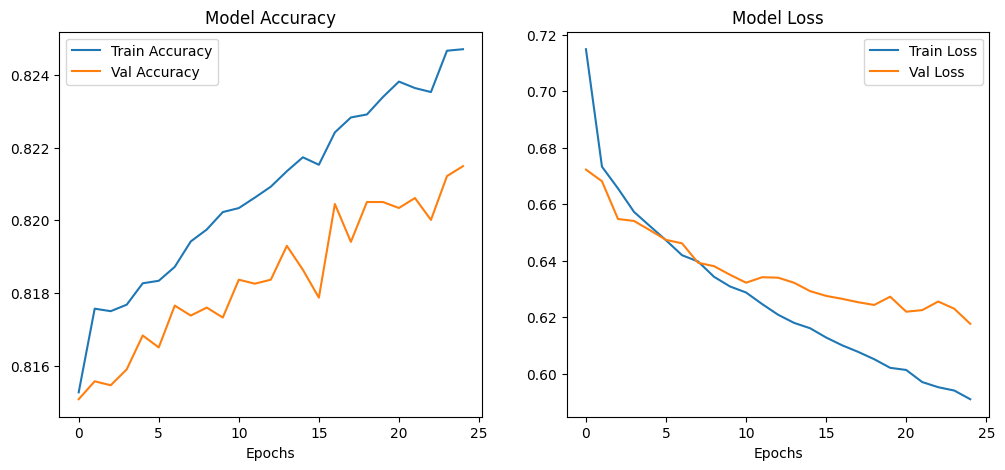

In [ ]:
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.legend()

plt.show()

In [ ]:
def get_genre_dna(test_index):
    # 1. Update 'le' to 'le_family' to match your encoder name
    actual_genre = le_family.inverse_transform([y_test[test_index]])[0]

    # 2. Predict probabilities
    probs = model.predict(X_test_scaled[test_index:test_index+1])[0]

    # 3. Get the top 3 matches
    top_indices = np.argsort(probs)[-3:][::-1]

    # 4. Again, update 'le' to 'le_family' here
    top_genres = le_family.inverse_transform(top_indices)
    top_probs = probs[top_indices]

    print(f"--- Music DNA for Test Song #{test_index} ---")
    print(f"Actual Label: {actual_genre}\n")
    print("Model's Top 3 Predictions:")
    for genre, p in zip(top_genres, top_probs):
        print(f"🧬 {genre}: {p*100:.2f}%")

# Try it out!
get_genre_dna(42)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
--- Music DNA for Test Song #42 ---
Actual Label: Blues/Jazz

Model's Top 3 Predictions:
🧬 Other/Indie: 97.05%
🧬 Electronic: 2.38%
🧬 Rock: 0.23%


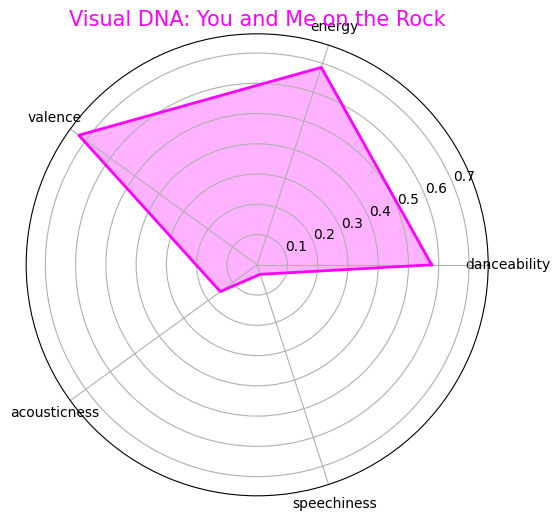

In [ ]:

def plot_visual_dna(test_index):
    # The 'Nucleotides' of your Music DNA
    features = ['danceability', 'energy', 'valence', 'acousticness', 'speechiness']
    values = data.iloc[test_index][features].values
    song_name = data.iloc[test_index]['track_name']

    # Create the Radar Chart
    angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
    values = np.concatenate((values, [values[0]]))
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.fill(angles, values, color='magenta', alpha=0.3)
    ax.plot(angles, values, color='magenta', linewidth=2)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features)

    plt.title(f"Visual DNA: {song_name}", size=15, color='magenta')
    plt.show()

# Run it for the same song you tested earlier
plot_visual_dna(42)

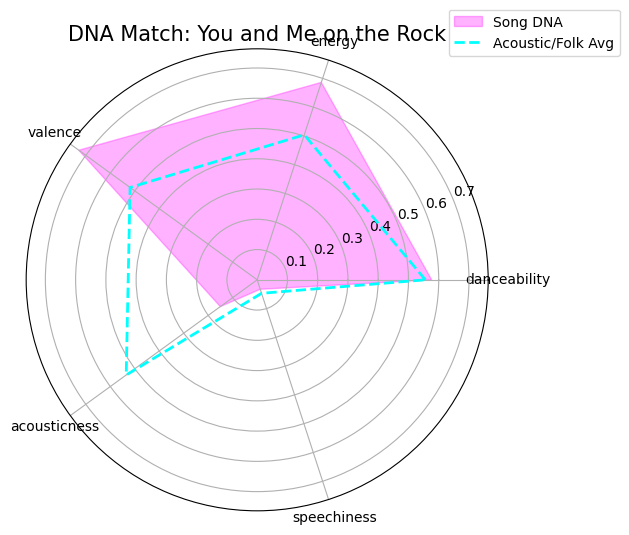

In [ ]:
def plot_dna_comparison(test_index):
    features = ['danceability', 'energy', 'valence', 'acousticness', 'speechiness']
    song_data = data.iloc[test_index]
    actual_family = song_data['genre_family']

    # Get the average DNA for this entire Genre Family
    family_avg = data[data['genre_family'] == actual_family][features].mean().values
    song_values = song_data[features].values

    # Setup plot
    angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    # Plot Song DNA
    ax.fill(angles, np.concatenate((song_values, [song_values[0]])), color='magenta', alpha=0.3, label="Song DNA")
    # Plot Genre Average DNA
    ax.plot(angles, np.concatenate((family_avg, [family_avg[0]])), color='cyan', linestyle='--', linewidth=2, label=f"{actual_family} Avg")

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.title(f"DNA Match: {song_data['track_name']}", size=15)
    plt.show()

plot_dna_comparison(42)

In [ ]:
from sklearn.metrics import multilabel_confusion_matrix, classification_report
import seaborn as sns



713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


ValueError: Classification metrics can't handle a mix of multiclass and multilabel-indicator targets

713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


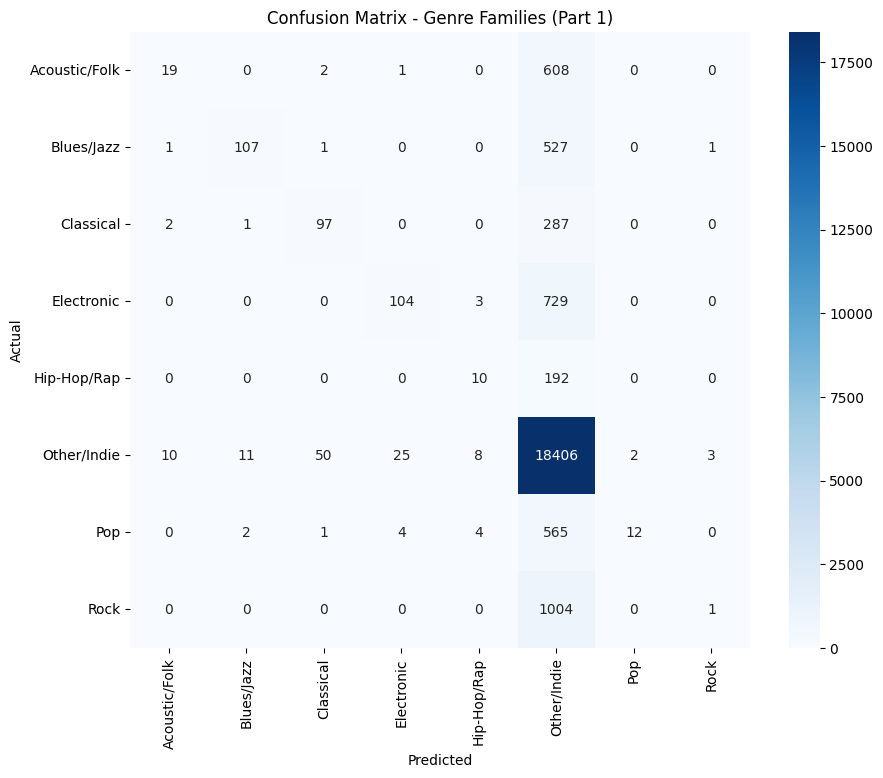

               precision    recall  f1-score   support

Acoustic/Folk       0.59      0.03      0.06       630
   Blues/Jazz       0.88      0.17      0.28       637
    Classical       0.64      0.25      0.36       387
   Electronic       0.78      0.12      0.21       836
  Hip-Hop/Rap       0.40      0.05      0.09       202
  Other/Indie       0.82      0.99      0.90     18515
          Pop       0.86      0.02      0.04       588
         Rock       0.20      0.00      0.00      1005

     accuracy                           0.82     22800
    macro avg       0.65      0.20      0.24     22800
 weighted avg       0.78      0.82      0.76     22800



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get predictions (indices of the highest probability)
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Generate a single standard Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Plot it
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_family.classes_,
            yticklabels=le_family.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Genre Families (Part 1)')
plt.show()

# 4. Print the report
print(classification_report(y_test, y_pred, target_names=le_family.classes_))